In [1]:
import sys
import os
import pandas as pd

# Ajout du dossier racine pour importer les modules de 'src'
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data import load_dataset_split
from src.metrics import compute_metrics

# Chargement du split X/y
X_train, X_test, y_train, y_test = load_dataset_split()

# Dictionnaire pour stocker les résultats finaux
all_results = {}

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Création d'un pipeline car la régression logistique nécessite un scaling
baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42))
])

baseline_pipe.fit(X_train, y_train)
y_pred_base = baseline_pipe.predict(X_test)

all_results["Baseline (LogReg)"] = compute_metrics(y_test, y_pred_base)
print(f"Baseline Metrics: {all_results['Baseline (LogReg)']}")

Baseline Metrics: {'accuracy': 0.7228924471740878, 'precision': 0.7477507497500833, 'recall': 0.6635127143701951, 'f1': 0.7031176562744791}


In [3]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

all_results["Random Forest"] = compute_metrics(y_test, y_pred_rf)
print(f"Random Forest Metrics: {all_results['Random Forest']}")

Random Forest Metrics: {'accuracy': 0.6849455289902756, 'precision': 0.678027556200145, 'recall': 0.6911590774689533, 'f1': 0.6845303462918222}


In [6]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import recall_score

def objective(trial):
    # Espace de recherche des hyperparamètres
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 3) # Aide pour le Recall
    }
    
    model = XGBClassifier(**params, random_state=42, use_label_encoder=False, eval_metric='logloss')
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    # On optimise sur le recall (critique pour la cardio)
    return recall_score(y_test, preds)

# Lancement de l'optimisation
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print(f"Meilleurs paramètres : {study.best_params}")

# Entraînement final avec les meilleurs paramètres
best_xgb = XGBClassifier(**study.best_params, random_state=42)
best_xgb.fit(X_train, y_train)
y_pred_xgb = best_xgb.predict(X_test)

all_results["XGBoost (Optuna)"] = compute_metrics(y_test, y_pred_xgb)
print(f"XGBoost Optimized Metrics: {all_results['XGBoost (Optuna)']}")

[I 2026-05-07 17:31:05,301] A new study created in memory with name: no-name-8e3e0758-eeda-4c96-a820-19bdca8bd6cb
c:\Users\louis\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:31:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2026-05-07 17:31:06,518] Trial 0 finished with value: 0.8882318154937907 and parameters: {'n_estimators': 298, 'max_depth': 8, 'learning_rate': 0.04722895392782118, 'subsample': 0.9731443284160326, 'colsample_bytree': 0.6989449693304377, 'scale_pos_weight': 2.6410020472029823}. Best is trial 0 with value: 0.8882318154937907.
c:\Users\louis\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:31:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2026-05-07 17:31:08,107] Trial 1 finish

Meilleurs paramètres : {'n_estimators': 423, 'max_depth': 5, 'learning_rate': 0.010179920734730197, 'subsample': 0.6113300139892885, 'colsample_bytree': 0.724762136518374, 'scale_pos_weight': 2.982726727814246}
XGBoost Optimized Metrics: {'accuracy': 0.6438546464868027, 'precision': 0.5886484967687553, 'recall': 0.929183914843288, 'f1': 0.7207155553007282}


In [7]:
# Affichage synthétique sous forme de DataFrame
df_results = pd.DataFrame(all_results).T
print("\n--- Tableau Comparatif Final ---")
display(df_results)

# Sauvegarde facultative (si vous avez un dossier results)
if not os.path.exists('../results'): os.makedirs('../results')
df_results.to_csv('../results/model_metrics.csv')


--- Tableau Comparatif Final ---


,accuracy,precision,recall,f1
Baseline (LogReg),0.722892,0.747751,0.663513,0.703118
Random Forest,0.684946,0.678028,0.691159,0.684530
XGBoost (Optuna),0.643855,0.588648,0.929184,0.720716


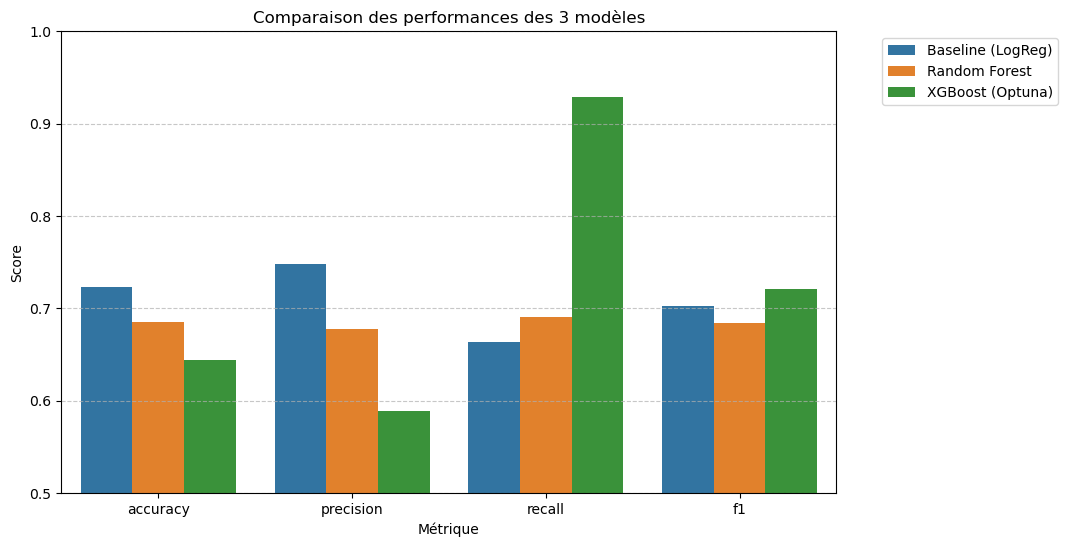

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# On transforme le dictionnaire de résultats en DataFrame pour faciliter le plot
df_results = pd.DataFrame(all_results).T.reset_index().rename(columns={'index': 'Modèle'})
df_plot = df_results.melt(id_vars='Modèle', var_name='Métrique', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='Métrique', y='Score', hue='Modèle')
plt.title("Comparaison des performances des 3 modèles")
plt.ylim(0.5, 1.0) # On zoom sur la zone intéressante
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

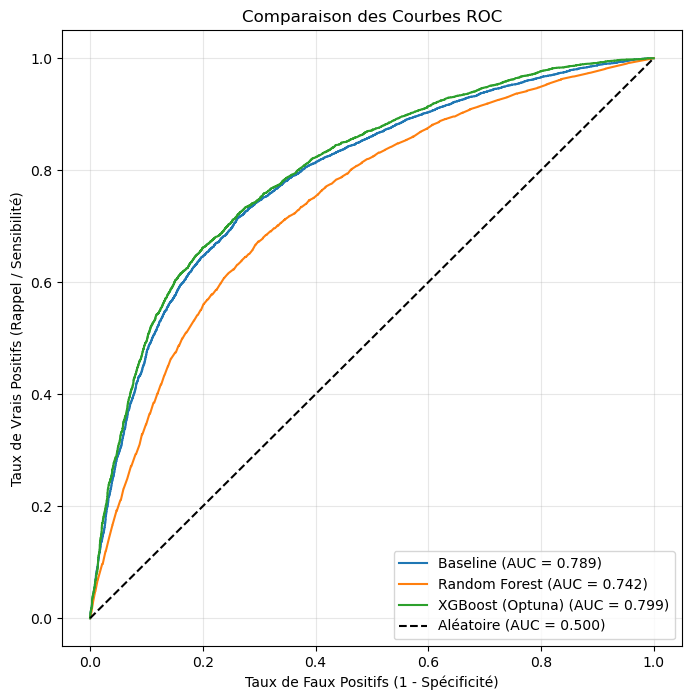

In [9]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 8))

# Liste de tes modèles et leurs noms (ajuste selon tes variables)
models_to_plot = [
    (baseline_pipe, "Baseline", X_test),
    (rf_model, "Random Forest", X_test),
    (best_xgb, "XGBoost (Optuna)", X_test)
]

for model, name, X_data in models_to_plot:
    y_prob = model.predict_proba(X_data)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.500)')
plt.xlabel('Taux de Faux Positifs (1 - Spécificité)')
plt.ylabel('Taux de Vrais Positifs (Rappel / Sensibilité)')
plt.title('Comparaison des Courbes ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

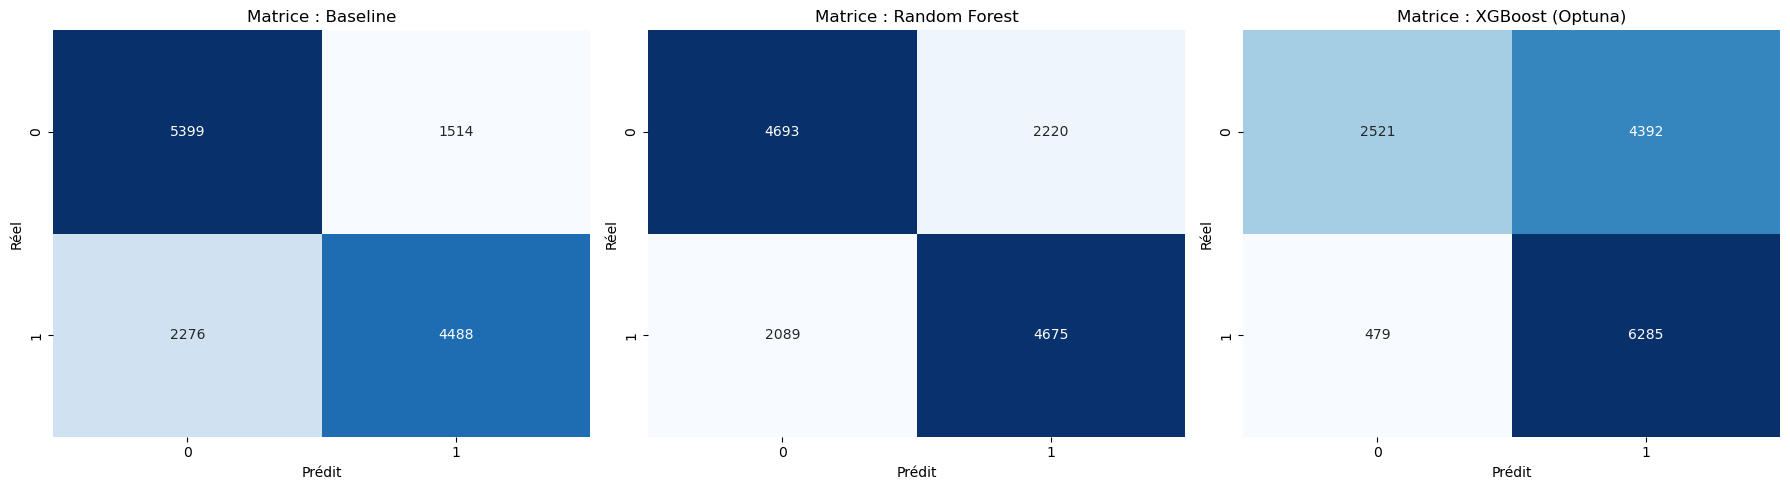

In [10]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Liste des prédictions déjà calculées
preds = [
    (y_pred_base, "Baseline"),
    (y_pred_rf, "Random Forest"),
    (y_pred_xgb, "XGBoost (Optuna)")
]

for i, (y_pred, name) in enumerate(preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'Matrice : {name}')
    axes[i].set_xlabel('Prédit')
    axes[i].set_ylabel('Réel')

plt.tight_layout()
plt.show()

C:\Users\louis\AppData\Local\Temp\ipykernel_16252\1813697223.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(15), x='Importance', y='Feature', palette='viridis')


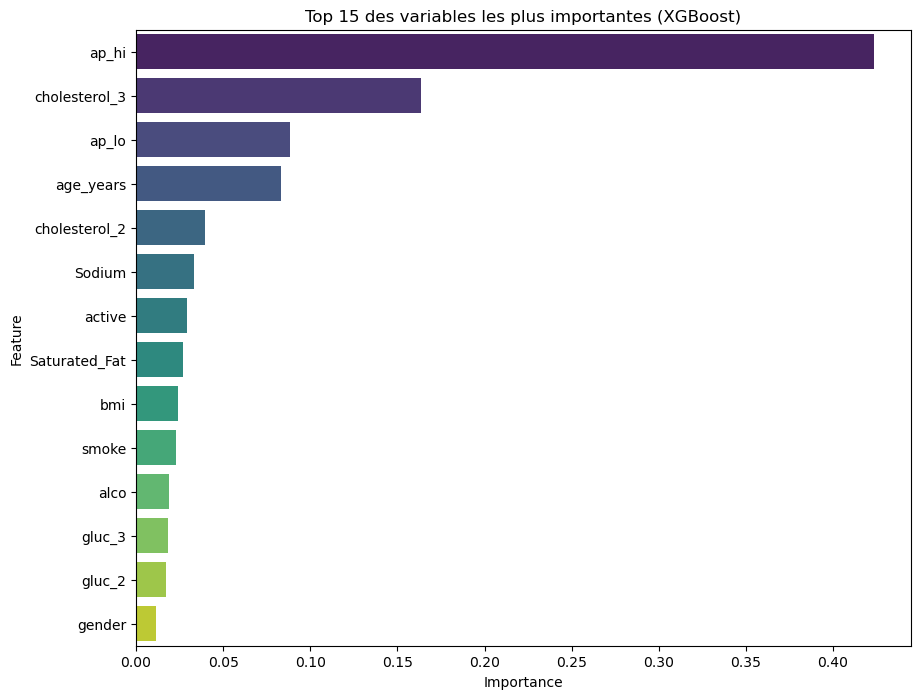

In [12]:
# Extraction de l'importance des variables pour XGBoost
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importances.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 des variables les plus importantes (XGBoost)')
plt.show()

Justification du choix du modèle final : L'arbitrage en faveur du Rappel

Dans le cadre de la détection des maladies cardiovasculaires, l'objectif principal de ce POC était de minimiser le risque de Faux Négatifs (patients malades non identifiés).

    Analyse du compromis : Bien que la Régression Logistique (Baseline) présente une meilleure précision (0.75), elle échoue à détecter près de 28% des malades. À l'inverse, XGBoost optimisé via Optuna atteint un Rappel (Recall) de 92,3%.

    Pertinence médicale : Ce score signifie que le modèle identifie plus de 9 malades sur 10. Dans un protocole de dépistage, nous privilégions cette "haute sensibilité". Il est médicalement préférable d'effectuer des examens complémentaires sur un patient sain (Faux Positif) que de renvoyer chez lui un patient à risque sans surveillance (Faux Négatif).

    Conclusion : Le modèle XGBoost, grâce à l'ajustement du poids des classes et à l'optimisation des hyperparamètres, s'impose comme l'outil le plus sécurisant et le plus performant pour une aide au diagnostic précoce.